# Qwen shared-prefix augmentation: M=1, 3, 5

Recitation, N=1,000 unique documents and keys. M=1 reuses the canonical Qwen-on-Qwen grid; M=3/5 use 3,000/5,000 texts. All arms train for 100 epochs. **Epoch 100 is the primary endpoint**, not a test-selected checkpoint. Equal epochs mean unequal optimizer-update budgets. The supplied ten-token prefixes are identical and are not included in the generated answers scored by Waterfall.

Tables are written to `src/eval/tables/ablations/`; figures to `src/eval/figures/ablations/qwen_prefix_augmentation/`. Missing data stay missing, not zero.

In [ ]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/util/filereader.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.eval.qwen_augmentation_eval import collect, collect_losses, export_rows
N = 1000
TABLE_DIR = ROOT / "src/eval/tables/ablations"
FIG_DIR = ROOT / "src/eval/figures/ablations/qwen_prefix_augmentation"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {1: "#333333", 3: "#0072B2", 5: "#D55E00"}
metrics = pd.DataFrame(collect(N))
losses = pd.DataFrame(collect_losses(N))
export_rows(metrics.to_dict("records"), f"qwen_prefix_augmentation_{N}")
export_rows(losses.to_dict("records"), f"qwen_prefix_augmentation_{N}_losses")
display(metrics.groupby("m")["status"].value_counts().unstack(fill_value=0))

status,complete
m,
1,20
3,20
5,20


# Epoch-100 comparison

Accuracy is a fraction in CSV exports and shown as a percentage below. Margin is the correct-key score minus the strongest competing-key score. Training evaluation losses refer to the pipeline's training-evaluation subset; held-out loss uses the unchanged held-out abstracts. Neither is a held-out-question generation metric.

In [ ]:
final = metrics[metrics.epoch.eq(100)].merge(
    losses[losses.epoch.eq(100)], on=["m", "n_documents", "epoch"], how="left")
columns = ["m", "n_documents", "n_training_texts", "status", "acc_at_1", "acc_at_5", "mean_margin", "train_loss", "heldout_loss", "global_step"]
final = final[columns]
final.to_csv(TABLE_DIR / f"qwen_prefix_augmentation_{N}_epoch100.csv", index=False)
display(final.style.format({"acc_at_1": "{:.1%}", "acc_at_5": "{:.1%}", "mean_margin": "{:.4f}", "train_loss": "{:.4f}", "heldout_loss": "{:.4f}"}, na_rep="missing"))

,m,n_documents,n_training_texts,status,acc_at_1,acc_at_5,mean_margin,train_loss,heldout_loss,global_step
0,1,1000,1000,complete,72.2%,76.6%,0.1301,0.0637,6.4479,3200
1,3,1000,3000,complete,56.8%,63.7%,0.0388,0.1197,6.1485,9400
2,5,1000,5000,complete,26.5%,32.8%,-0.0954,0.3359,5.9292,15700


# Attribution trajectories

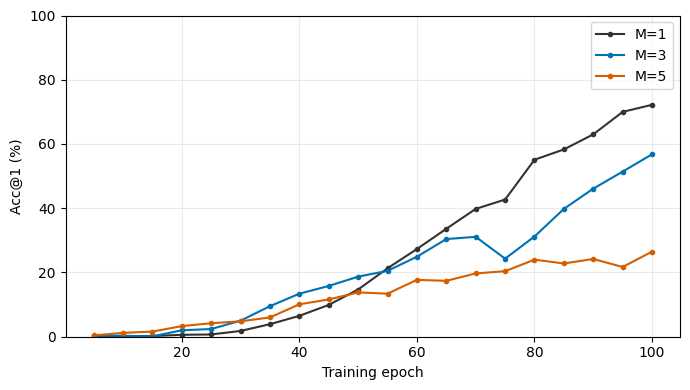

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for m, group in metrics.groupby("m"):
    group = group.sort_values("epoch")
    ax.plot(group.epoch, 100 * group.acc_at_1, marker="o", markersize=3, color=COLORS[m], label=f"M={m}")
ax.set(xlabel="Training epoch", ylabel="Acc@1 (%)", ylim=(0, 100))
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "acc_at_1.pdf")
plt.show()

# Loss trajectories

The epoch plot matches the 100-epoch design. The optimizer-step plot makes the additional training compute visible; it is not an exact token-compute-matched comparison.

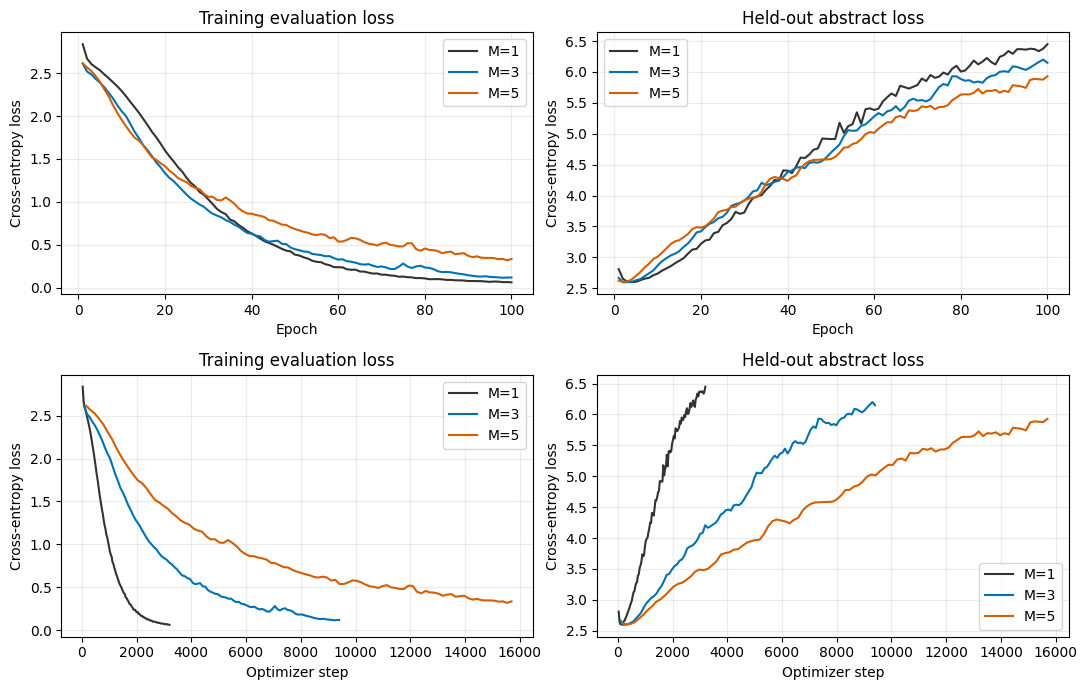

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey="col")
for row, x in enumerate(["epoch", "global_step"]):
    for col, (metric, title) in enumerate([("train_loss", "Training evaluation loss"), ("heldout_loss", "Held-out abstract loss")]):
        ax = axes[row, col]
        for m, group in losses.groupby("m"):
            ax.plot(group[x], group[metric], color=COLORS[m], label=f"M={m}")
        ax.set(xlabel="Epoch" if x == "epoch" else "Optimizer step", ylabel="Cross-entropy loss", title=title)
        ax.grid(alpha=.25)
        ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "loss_trajectories.pdf")
plt.show()

# Interpretation boundary

These results test attribution under familiar shared prefixes. A decrease in attribution does not itself demonstrate improved semantic generalization. Direct source-watermark quality and output-reference overlap are separate checks; no held-out-question generation is included in this ablation yet.